In [1]:
import yaml
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
import numpy as np
import re
import numpy as np
import matplotlib.pyplot as plt
from typing import Any, Dict, List, Optional, Tuple, Union
import pandas as pd

#from typing import Any, Dict, List, Union


from tqdm import tqdm
import json

from thesis_project.models.keyword_spotting import KWSBase, KWSDynamic
from thesis_project.models.components.routers import GRURouter
from thesis_project.utils.paths import get_data_dir
from thesis_project.datasets import SpeechCommandsGoogle
#from thesis_project.training.key_word_spotting.train_base_loop import fit_base_model, validate_model
from base_config_temp import cfg, noise_train_cfg, noise_eval_cfg

MODEL_DIR = "/Users/christoffer/Documents/Thesis/thesis_project/model_runs/base/2025-12-14_18-48-50/"
MODEL_CHECKPOINT = MODEL_DIR + "best_model.pth"
MODEL_HISTORY = np.load(MODEL_DIR + "history.npy", allow_pickle=True).item()

In [3]:
# Load per-sample results from CSV files
all_per_sample_dfs = {}
comb_names = ["comb_1"]  # Add other combination names if needed
for comb_name in comb_names:
    df = pd.read_csv(MODEL_DIR + f"per_sample_results_{comb_name}_golden.csv")
    all_per_sample_dfs[comb_name] = df

print(f"\nLoaded per-sample results from {MODEL_DIR}:")


Loaded per-sample results from /Users/christoffer/Documents/Thesis/thesis_project/model_runs/base/2025-12-14_18-48-50/:


### Analysis of results for combination 1

In [13]:
df_for_viz = all_per_sample_dfs["comb_1"]
# get the length of a single validation set (samples per snr_eval, rank combo)
# Since samples are in the same order for all noise files, we can compute length from any group
len_single_val_set = df_for_viz.groupby(['val_set_id', 'snr_eval', 'rank']).size().iloc[0]
print(f"Length of single validation set: {len_single_val_set}")

# Assigning an ID to each sample based on its position within each (snr_eval, rank) group
# This ID is consistent across all val_set_id (noise files) since samples are loaded in same order
df_for_viz['id'] = df_for_viz.groupby(['snr_eval', 'rank']).cumcount() % len_single_val_set

# Verify: each (id, snr_eval, rank) should have exactly NUMBER_OF_VAL_SETS rows (one per noise file)
print(f"Unique noise files: {df_for_viz['noise_file'].unique().tolist()}")
print(f"Rows per (id, snr_eval, rank): {df_for_viz.groupby(['id', 'snr_eval', 'rank']).size().iloc[0]} (expected: {len(df_for_viz['val_set_id'].unique())})")

Length of single validation set: 4515
Unique noise files: ['doing_the_dishes.wav', 'dude_miaowing.wav', 'exercise_bike.wav', 'pink_noise.wav', 'running_tap.wav', 'white_noise.wav']
Rows per (id, snr_eval, rank): 6 (expected: 6)


In [14]:
import math
import pandas as pd
import matplotlib.pyplot as plt


def plot_min_correct_rank_distributions_grid(
    df: pd.DataFrame,
    *,
    snr_col: str = "snr_eval",
    rank_col: str = "rank",
    correct_col: str = "correct",
    id_col: str = "id",
    normalize: bool = True,
    figsize_per_plot=(5, 4),
    ncols: int = 3,
):
    """
    Grid of plots (one per SNR):
      - histogram of min rank where each sample becomes correct
      - shared x/y limits across all SNR plots
      - overlays mean / median / mode / 95th percentile
      - each subplot has its OWN legend with numeric values
      - x ticks shown on ALL plots and are every other integer
    """

    needed = {snr_col, rank_col, correct_col, id_col}
    missing = needed - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    # --- keep only rows where prediction is correct ---
    correct_df = df[df[correct_col].astype(bool)]

    # --- min rank where sample becomes correct ---
    min_rank_df = (
        correct_df
        .groupby([snr_col, id_col])[rank_col]
        .min()
        .reset_index(name="min_rank")
    )

    # --- all samples (to detect never-correct) ---
    all_samples = df[[snr_col, id_col]].drop_duplicates()

    per_sample = all_samples.merge(
        min_rank_df,
        on=[snr_col, id_col],
        how="left",
    )

    # -------------------------------------------------
    # PRECOMPUTE GLOBAL AXIS LIMITS
    # -------------------------------------------------
    all_ranks = per_sample["min_rank"].dropna().astype(int)
    if len(all_ranks) == 0:
        return per_sample

    xmin, xmax = int(all_ranks.min()), int(all_ranks.max())

    ymax = 0.0
    for _, sub in per_sample.groupby(snr_col, sort=False):
        ranks = sub["min_rank"].dropna().astype(int)
        if len(ranks) == 0:
            continue
        counts = ranks.value_counts().sort_index()
        y = counts.to_numpy()
        if normalize:
            y = y / y.sum()
        ymax = max(ymax, float(y.max()))

    # -------------------------------------------------
    # GRID SETUP
    # -------------------------------------------------
    snrs = list(per_sample[snr_col].drop_duplicates())
    n_plots = len(snrs)
    nrows = math.ceil(n_plots / ncols)

    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(figsize_per_plot[0] * ncols, figsize_per_plot[1] * nrows),
        sharex=True,
        sharey=True,
    )
    axes = axes.flatten() if n_plots > 1 else [axes]

    xticks = list(range(xmin, xmax + 1, 2))

    # -------------------------------------------------
    # PLOT PER SNR
    # -------------------------------------------------
    for ax, snr in zip(axes, snrs):
        sub = per_sample[per_sample[snr_col] == snr]
        ranks = sub["min_rank"].dropna().astype(int)

        total = len(sub)
        never = int(sub["min_rank"].isna().sum())
        never_pct = 100.0 * never / total if total else 0.0

        if len(ranks) > 0:
            counts = ranks.value_counts().sort_index()
            x = counts.index.to_numpy()
            y = counts.to_numpy()

            if normalize:
                y = y / y.sum()

            ax.bar(x, y)

            # ---- statistics ----
            mean_rank = float(ranks.mean())
            median_rank = float(ranks.median())
            mode_rank = int(ranks.mode().iloc[0])
            p95_rank = float(ranks.quantile(0.95))

            ax.axvline(mean_rank, linestyle="--", linewidth=2,
                       label=f"Mean = {mean_rank:.2f}",color="C1")
            ax.axvline(median_rank, linestyle="-", linewidth=2,
                       label=f"Median = {median_rank:.2f}", color="C2")
            ax.axvline(mode_rank, linestyle=":", linewidth=2,
                       label=f"Mode = {mode_rank}",color="C3")
            ax.axvline(p95_rank, linestyle="-.", linewidth=2,
                       label=f"P95 = {p95_rank:.2f}",color="C4")

            ax.legend(frameon=False, fontsize=9)

        else:
            ax.text(0.5, 0.5, "No correct samples",
                    ha="center", va="center", transform=ax.transAxes)

        ax.set_title(
            f"SNR={snr}\nnever: {never}/{total} ({never_pct:.1f}%)",
            fontsize=10,
        )

        ax.set_xlim(xmin - 0.5, xmax + 0.5)
        ax.set_ylim(0, ymax * 1.05)
        ax.grid(axis="y", alpha=0.3)

        # ---- force x ticks on all plots ----
        ax.set_xticks(xticks)
        ax.set_xticklabels(xticks, rotation=90)
        ax.tick_params(axis="x", labelbottom=True)

    # hide unused axes
    for ax in axes[n_plots:]:
        ax.axis("off")

    # -------------------------------------------------
    # GLOBAL LABELS
    # -------------------------------------------------
    fig.text(0.5, 0.04, "Minimum rank where sample is correct", ha="center")
    fig.text(
        0.04,
        0.5,
        "Probability" if normalize else "Count",
        va="center",
        rotation="vertical",
    )

    fig.tight_layout(rect=[0.05, 0.05, 0.95, 0.95])
    plt.show()

    return per_sample

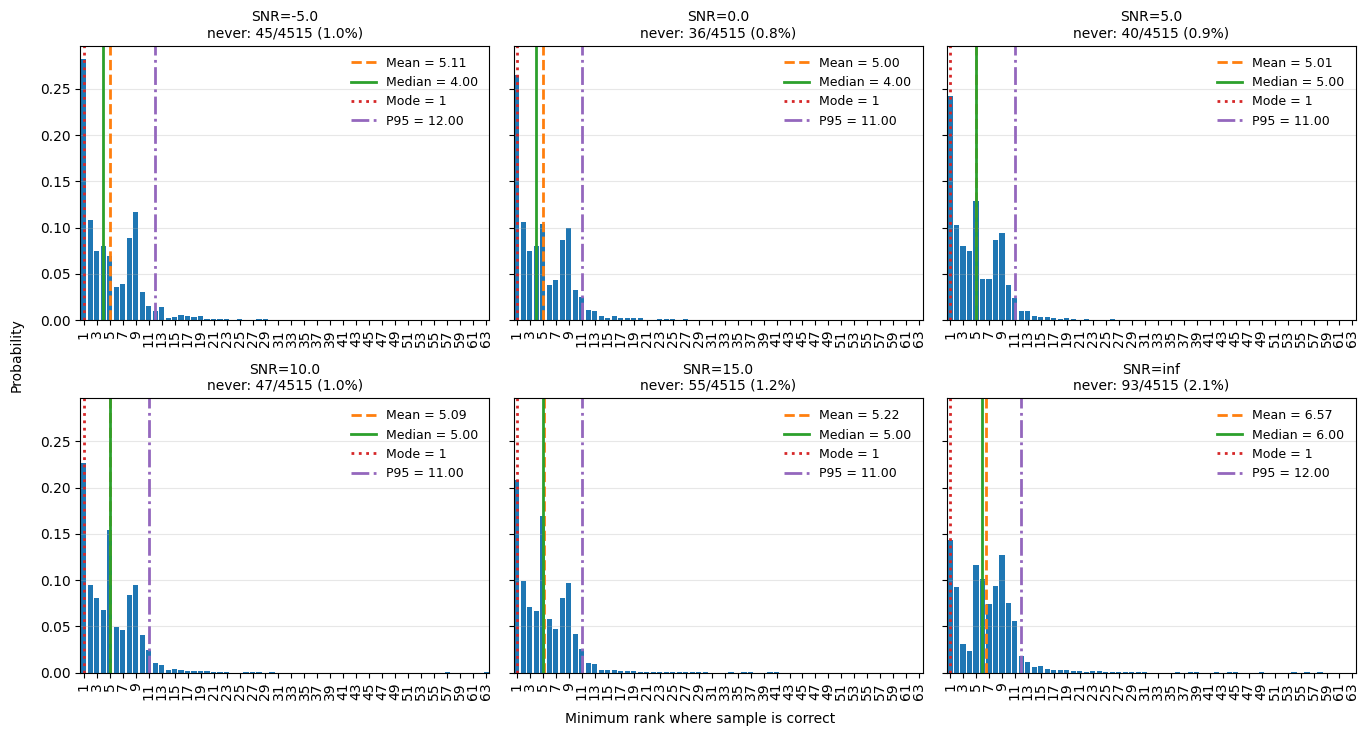

In [15]:
per_sample_min_correct_rank = plot_min_correct_rank_distributions_grid(
    df=df_for_viz,
    normalize=True,
)

In [19]:
def plot_min_correct_rank_by_noise_type(
    df: pd.DataFrame,
    snr_value: float,
    *,
    snr_col: str = "snr_eval",
    rank_col: str = "rank",
    correct_col: str = "correct",
    id_col: str = "id",
    noise_col: str = "noise_file",  # or "val_set_id"
    normalize: bool = True,
    figsize_per_plot: Tuple[float, float] = (8, 2),
    color: str = "C0",
):
    """
    For a given SNR value, plot the histogram of minimum rank where each sample
    becomes correct, with one subplot per noise type/validation set.
    
    Plots are stacked vertically with a shared x-axis to easily visualize
    distribution shifts across noise types.
    
    Parameters
    ----------
    df : pd.DataFrame
        DataFrame with per-sample results
    snr_value : float
        The SNR value to filter on
    snr_col : str
        Column name for SNR values
    rank_col : str
        Column name for rank values
    correct_col : str
        Column name for correctness (bool or 0/1)
    id_col : str
        Column name for sample ID
    noise_col : str
        Column name for noise type / validation set identifier
    normalize : bool
        If True, show probability; if False, show counts
    figsize_per_plot : tuple
        (width, height) per subplot
    color : str
        Bar color
        
    Returns
    -------
    per_sample : pd.DataFrame
        DataFrame with min_rank per sample and noise type
    """
    
    needed = {snr_col, rank_col, correct_col, id_col, noise_col}
    missing = needed - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")
    
    # Filter to the specified SNR
    df_snr = df[df[snr_col] == snr_value].copy()
    if len(df_snr) == 0:
        raise ValueError(f"No data found for SNR={snr_value}")
    
    # Keep only correct predictions
    correct_df = df_snr[df_snr[correct_col].astype(bool)]
    
    # Min rank where sample becomes correct (per noise type)
    min_rank_df = (
        correct_df
        .groupby([noise_col, id_col])[rank_col]
        .min()
        .reset_index(name="min_rank")
    )
    
    # All samples per noise type
    all_samples = df_snr[[noise_col, id_col]].drop_duplicates()
    
    per_sample = all_samples.merge(
        min_rank_df,
        on=[noise_col, id_col],
        how="left",
    )
    
    # Compute global x-axis limits
    all_ranks = per_sample["min_rank"].dropna().astype(int)
    if len(all_ranks) == 0:
        print("No correct samples found for this SNR")
        return per_sample
    
    xmin, xmax = int(all_ranks.min()), int(all_ranks.max())
    
    # Compute mean across all noise types (per sample id, averaged)
    # For each sample id, compute mean min_rank across noise types
    mean_per_sample = (
        per_sample
        .groupby(id_col)["min_rank"]
        .mean()
        .reset_index(name="min_rank")
    )
    mean_per_sample[noise_col] = "MEAN (all noise types)"
    
    # Combine individual noise types + mean
    per_sample_with_mean = pd.concat([per_sample, mean_per_sample], ignore_index=True)
    
    # Compute global y-axis limit (include mean in calculation)
    ymax = 0.0
    noise_types = sorted(per_sample[noise_col].unique())
    noise_types_with_mean = noise_types + ["MEAN (all noise types)"]
    
    for noise_type in noise_types_with_mean:
        sub = per_sample_with_mean[per_sample_with_mean[noise_col] == noise_type]
        ranks = sub["min_rank"].dropna()
        if len(ranks) == 0:
            continue
        # For mean plot, round to nearest int for histogram
        ranks_int = ranks.round().astype(int)
        counts = ranks_int.value_counts().sort_index()
        y = counts.to_numpy()
        if normalize:
            y = y / y.sum()
        ymax = max(ymax, float(y.max()))
    
    # Create vertically stacked subplots with shared x-axis
    # +1 for the mean plot
    n_plots = len(noise_types) + 1
    fig, axes = plt.subplots(
        n_plots,
        1,
        figsize=(figsize_per_plot[0], figsize_per_plot[1] * n_plots),
        sharex=True,
        sharey=True,
    )
    
    if n_plots == 1:
        axes = [axes]
    
    xticks = list(range(xmin, xmax + 1, 2))
    
    # Plot individual noise types
    for ax, noise_type in zip(axes[:-1], noise_types):
        sub = per_sample[per_sample[noise_col] == noise_type]
        ranks = sub["min_rank"].dropna().astype(int)
        
        total = len(sub)
        never = int(sub["min_rank"].isna().sum())
        never_pct = 100.0 * never / total if total else 0.0
        
        if len(ranks) > 0:
            counts = ranks.value_counts().sort_index()
            x = counts.index.to_numpy()
            y = counts.to_numpy()
            
            if normalize:
                y = y / y.sum()
            
            ax.bar(x, y, color=color, alpha=0.7, edgecolor="black", linewidth=0.5)
            
            # Statistics
            mean_rank = float(ranks.mean())
            median_rank = float(ranks.median())
            mode_rank = int(ranks.mode().iloc[0])
            
            ax.axvline(mean_rank, linestyle="--", linewidth=1.5,
                       label=f"Mean={mean_rank:.1f}", color="C1")
            ax.axvline(median_rank, linestyle="-", linewidth=1.5,
                       label=f"Median={median_rank:.1f}", color="C2")
            ax.axvline(mode_rank, linestyle=":", linewidth=1.5,
                       label=f"Mode={mode_rank}", color="C3")
            
            ax.legend(loc="upper right", frameon=False, fontsize=8, ncol=3)
        else:
            ax.text(0.5, 0.5, "No correct samples",
                    ha="center", va="center", transform=ax.transAxes)
        
        # Clean up noise file name for display
        noise_label = noise_type.split("/")[-1] if "/" in str(noise_type) else str(noise_type)
        ax.set_ylabel(f"{noise_label}\n(never: {never_pct:.1f}%)", fontsize=9)
        
        ax.set_xlim(xmin - 0.5, xmax + 0.5)
        ax.set_ylim(0, ymax * 1.1)
        ax.grid(axis="y", alpha=0.3)
    
    # Plot mean across all noise types (last subplot)
    ax_mean = axes[-1]
    mean_ranks = mean_per_sample["min_rank"].dropna()
    
    total_mean = len(mean_per_sample)
    never_mean = int(mean_per_sample["min_rank"].isna().sum())
    never_pct_mean = 100.0 * never_mean / total_mean if total_mean else 0.0
    
    if len(mean_ranks) > 0:
        # Round to nearest int for histogram bins
        mean_ranks_int = mean_ranks.round().astype(int)
        counts = mean_ranks_int.value_counts().sort_index()
        x = counts.index.to_numpy()
        y = counts.to_numpy()
        
        if normalize:
            y = y / y.sum()
        
        ax_mean.bar(x, y, color="C4", alpha=0.7, edgecolor="black", linewidth=0.5)
        
        # Statistics (on original float values)
        mean_val = float(mean_ranks.mean())
        median_val = float(mean_ranks.median())
        mode_val = int(mean_ranks_int.mode().iloc[0])
        
        ax_mean.axvline(mean_val, linestyle="--", linewidth=1.5,
                        label=f"Mean={mean_val:.1f}", color="C1")
        ax_mean.axvline(median_val, linestyle="-", linewidth=1.5,
                        label=f"Median={median_val:.1f}", color="C2")
        ax_mean.axvline(mode_val, linestyle=":", linewidth=1.5,
                        label=f"Mode={mode_val}", color="C3")
        
        ax_mean.legend(loc="upper right", frameon=False, fontsize=8, ncol=3)
    else:
        ax_mean.text(0.5, 0.5, "No correct samples",
                     ha="center", va="center", transform=ax_mean.transAxes)
    
    ax_mean.set_ylabel(f"MEAN\n(never: {never_pct_mean:.1f}%)", fontsize=9, fontweight="bold")
    ax_mean.set_xlim(xmin - 0.5, xmax + 0.5)
    ax_mean.set_ylim(0, ymax * 1.1)
    ax_mean.grid(axis="y", alpha=0.3)
    
    # Set x-axis label and ticks on bottom plot
    axes[-1].set_xlabel("Minimum rank where sample is correct", fontsize=10)
    axes[-1].set_xticks(xticks)
    
    # Title
    fig.suptitle(
        f"Min Correct Rank Distribution by Noise Type (SNR={snr_value})",
        fontsize=12,
        y=1.02,
    )
    
    plt.tight_layout()
    plt.show()
    
    return per_sample

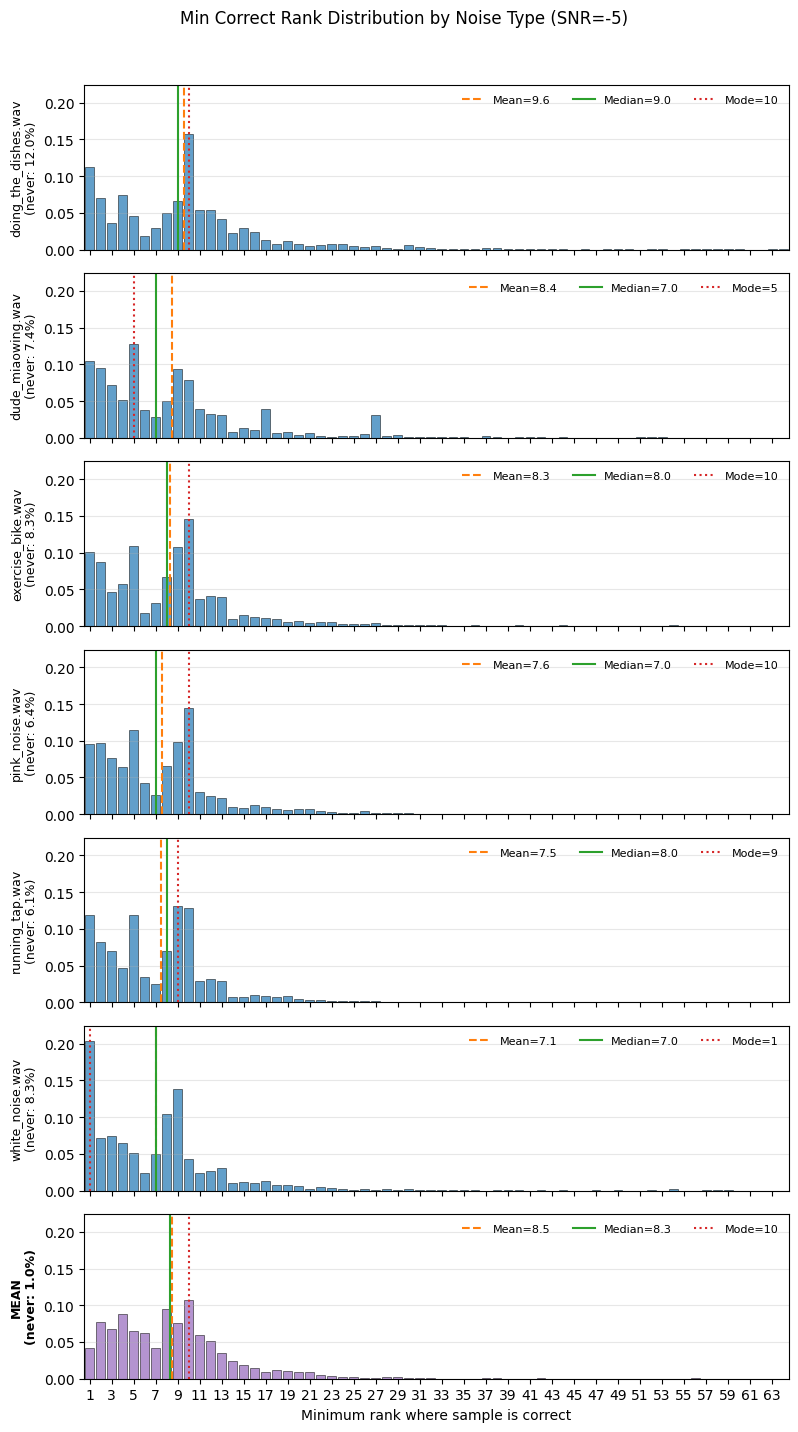

In [20]:
# Example: Plot min correct rank distribution by noise type for a specific SNR
# Change snr_value to the SNR you want to analyze
snr_value = -5  # Adjust this to your desired SNR value

per_sample_by_noise = plot_min_correct_rank_by_noise_type(
    df=df_for_viz,
    snr_value=snr_value,
    normalize=True,
)

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_rank_vs_acc_per_snr(
    df: pd.DataFrame,
    *,
    include_silence: bool = True,
    y_mode: str = "acc",                 # "acc" or "ratio"
    ratio_target: float = 0.8,           # only used when y_mode="ratio"
    plot_per_snr: bool = True,           # NEW: toggle individual SNR plots
    silence_label: str = "SILENCE",
    label_col: str = "label",
    snr_col: str = "snr_eval",
    rank_col: str = "rank",
    correct_col: str = "correct",
    figsize_all=(7, 5),
    figsize_single=(6, 4),
    marker="o",
    print_ratio_summary: bool = True,
):
    """
    Plots:
      1) One plot with ALL SNR curves together (always)
      2) Optionally (plot_per_snr=True) one plot per SNR

    y_mode:
      - "acc"   : accuracy in %
      - "ratio" : accuracy / max_accuracy_per_SNR

    When y_mode="ratio", optionally prints and returns a summary table with
    the minimum rank needed to reach `ratio_target` for each SNR.

    Returns
    -------
    summary : pd.DataFrame
        MultiIndex (rank, snr_eval) with columns:
        [acc_all, acc_non_silence, acc_diff, acc_ratio]
    ratio_rank_summary : pd.DataFrame or None
        Per-SNR summary of min rank to reach ratio_target (only when y_mode="ratio")
    """

    if y_mode not in {"acc", "ratio"}:
        raise ValueError("y_mode must be 'acc' or 'ratio'")

    if y_mode == "ratio" and not (0 < ratio_target <= 1.0):
        raise ValueError("ratio_target must be in (0, 1] when y_mode='ratio'")

    # --- Checks ---
    needed = {snr_col, rank_col, correct_col, label_col}
    missing = needed - set(df.columns)
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    # --- Accuracy including silence ---
    g_all = (
        df.assign(is_silence=df[label_col] == silence_label)
          .groupby([rank_col, snr_col], dropna=False)
    )
    acc_all = g_all[correct_col].mean() * 100

    # --- Accuracy excluding silence ---
    df_ns = df[df[label_col] != silence_label]
    acc_non_silence = (
        df_ns.groupby([rank_col, snr_col], dropna=False)[correct_col]
             .mean()
             .mul(100)
    )

    # --- Summary (MultiIndex: rank, snr) ---
    summary = (
        pd.concat(
            {"acc_all": acc_all, "acc_non_silence": acc_non_silence},
            axis=1,
        )
        .assign(acc_diff=lambda d: d["acc_all"] - d["acc_non_silence"])
        .sort_index()
    )

    acc_col = "acc_all" if include_silence else "acc_non_silence"

    # --- Add normalized ratio per SNR ---
    max_acc_per_snr = summary.groupby(level=snr_col)[acc_col].transform("max")
    summary["acc_ratio"] = summary[acc_col] / max_acc_per_snr

    # --- Build ratio->rank summary if needed ---
    ratio_rank_summary = None
    if y_mode == "ratio":
        tmp = summary.reset_index().sort_values([snr_col, rank_col])

        rows = []
        for snr, sub in tmp.groupby(snr_col, sort=False):
            hit = sub[sub["acc_ratio"] >= ratio_target]
            if len(hit) > 0:
                min_rank = int(hit[rank_col].iloc[0])
                achieved_ratio = float(hit["acc_ratio"].iloc[0])
                achieved_acc = float(hit[acc_col].iloc[0])
            else:
                min_rank = None
                achieved_ratio = float(sub["acc_ratio"].max()) if len(sub) else float("nan")
                achieved_acc = float(sub[acc_col].max()) if len(sub) else float("nan")

            rows.append(
                {
                    snr_col: snr,
                    "min_rank_for_ratio": min_rank,
                    "ratio_target": ratio_target,
                    "achieved_ratio_at_min_rank": achieved_ratio if min_rank is not None else None,
                    "acc_at_min_rank": achieved_acc if min_rank is not None else None,
                    "max_acc": float(sub[acc_col].max()) if len(sub) else float("nan"),
                }
            )

        ratio_rank_summary = pd.DataFrame(rows).sort_values(snr_col)

        if print_ratio_summary:
            print(
                f"\n=== Minimum rank to reach acc/max(acc) ≥ {ratio_target:.2f} "
                f"({'acc_all' if include_silence else 'acc_non_silence'}) ==="
            )
            print(ratio_rank_summary.to_string(index=False))

    # =========================
    # 1) ALL SNRs IN ONE PLOT
    # =========================
    plt.figure(figsize=figsize_all)

    for snr in summary.index.get_level_values(snr_col).unique():
        sub = summary.xs(snr, level=snr_col).reset_index()
        y = sub["acc_ratio"] if y_mode == "ratio" else sub[acc_col]

        plt.plot(
            sub[rank_col],
            y,
            marker=marker,
            label=f"SNR={snr}",
        )

    plt.xlabel("Rank")
    ylabel = "Accuracy / max(Accuracy)" if y_mode == "ratio" else "Accuracy (%)"
    plt.ylabel(ylabel)
    plt.title(f"Rank vs {ylabel} — all SNRs")
    plt.grid(True)

    if y_mode == "ratio":
        plt.axhline(ratio_target, linestyle="--")
    plt.legend(title="SNR")
    plt.tight_layout()
    plt.show()

    # =========================
    # 2) OPTIONAL: ONE PLOT PER SNR
    # =========================
    if plot_per_snr:
        for snr in summary.index.get_level_values(snr_col).unique():
            sub = summary.xs(snr, level=snr_col).reset_index()
            y = sub["acc_ratio"] if y_mode == "ratio" else sub[acc_col]

            plt.figure(figsize=figsize_single)
            plt.plot(sub[rank_col], y, marker=marker)
            plt.xlabel("Rank")
            plt.ylabel(ylabel)
            plt.title(f"Rank vs {ylabel} (SNR={snr})")
            plt.grid(True)

            if y_mode == "ratio":
                plt.axhline(ratio_target, linestyle="--")

                # vertical line at min rank (if exists)
                if ratio_rank_summary is not None:
                    r = ratio_rank_summary.loc[
                        ratio_rank_summary[snr_col] == snr, "min_rank_for_ratio"
                    ]
                    if len(r) and pd.notna(r.iloc[0]):
                        plt.axvline(int(r.iloc[0]), linestyle="--")

            plt.tight_layout()
            plt.show()

    return summary, ratio_rank_summary

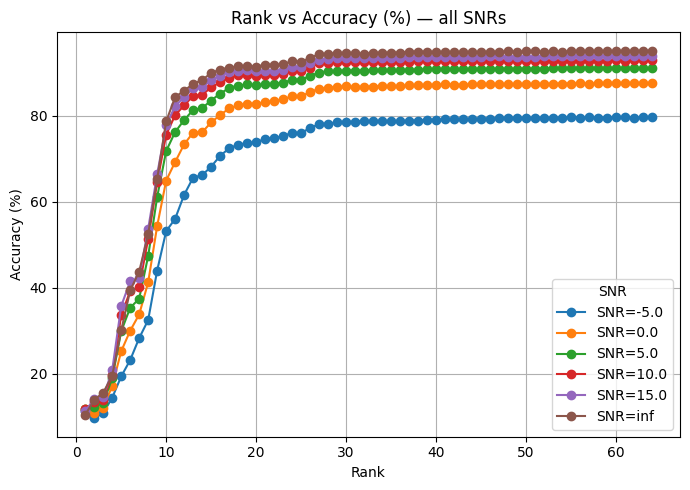


=== Minimum rank to reach acc/max(acc) ≥ 0.95 (acc_all) ===
 snr_eval  min_rank_for_ratio  ratio_target  achieved_ratio_at_min_rank  acc_at_min_rank   max_acc
     -5.0                  24          0.95                    0.955509        76.028055 79.568106
      0.0                  22          0.95                    0.952011        83.337025 87.537837
      5.0                  18          0.95                    0.955048        86.976744 91.070506
     10.0                  17          0.95                    0.956306        88.789221 92.846069
     15.0                  16          0.95                    0.951836        89.291251 93.809524
      inf                  16          0.95                    0.953952        90.697674 95.075674


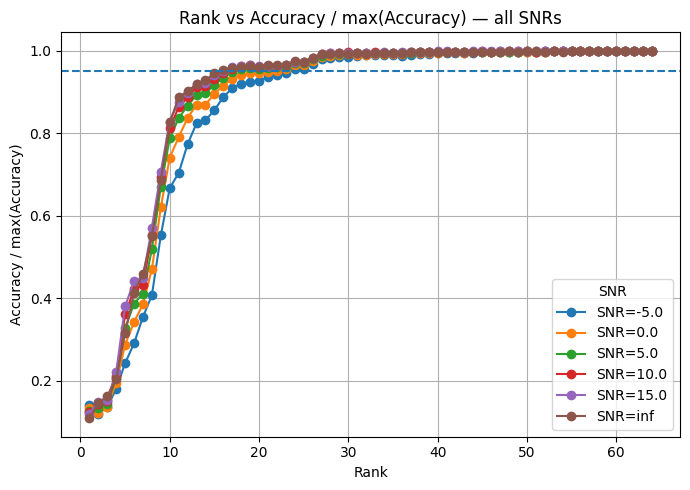

In [8]:
# Normal accuracy plots
summary, ratio_tbl = plot_rank_vs_acc_per_snr(df, include_silence=True, y_mode="acc",plot_per_snr=False)

# Ratio plots + printed table of min rank per SNR to reach 0.8
summary, ratio_tbl = plot_rank_vs_acc_per_snr(
    df,
    include_silence=True,
    y_mode="ratio",
    ratio_target=0.95,
    print_ratio_summary=True,
    plot_per_snr=False,
)